In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
conn = sqlite3.connect('data/checking-logs.sqlite')

In [3]:
checker = pd.io.sql.read_sql(
    "SELECT uid, timestamp FROM checker WHERE uid LIKE 'user_%';",
    conn,
    parse_dates=['timestamp']
)
checker

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [4]:
checker['weekday'] = checker['timestamp'].dt.day_name()
checker['hour'] = checker['timestamp'].dt.hour
checker

,uid,timestamp,weekday,hour
0,user_4,2020-04-17 05:19:02.744528,Friday,5
1,user_4,2020-04-17 05:22:35.249331,Friday,5
2,user_4,2020-04-17 05:22:45.549397,Friday,5
3,user_4,2020-04-17 05:34:14.691200,Friday,5
4,user_4,2020-04-17 05:34:24.422370,Friday,5
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,Thursday,20
3203,user_1,2020-05-21 20:22:41.785725,Thursday,20
3204,user_1,2020-05-21 20:22:41.877806,Thursday,20
3205,user_1,2020-05-21 20:37:00.129678,Thursday,20


In [5]:
weekday_pivot = checker.groupby(['weekday', 'uid']).size().reset_index(name='commits')
weekday_pivot = weekday_pivot.pivot(index='weekday', columns='uid', values='commits').fillna(0)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_pivot = weekday_pivot.reindex(weekday_order)
total_commits_by_user = weekday_pivot.sum(axis=0).sort_values(ascending=False)
weekday_pivot = weekday_pivot[total_commits_by_user.index]
weekday_pivot

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
weekday,,,,,,,,,,,,,,,,,,,,,
Monday,35.0,50.0,24.0,14.0,7.0,0.0,23.0,5.0,0.0,46.0,...,8.0,10.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,3.0
Tuesday,86.0,87.0,131.0,44.0,9.0,1.0,0.0,0.0,16.0,11.0,...,4.0,5.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0
Wednesday,33.0,0.0,32.0,15.0,0.0,34.0,8.0,0.0,37.0,0.0,...,1.0,0.0,0.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0
Thursday,108.0,17.0,4.0,40.0,78.0,51.0,96.0,7.0,77.0,7.0,...,17.0,14.0,15.0,5.0,2.0,0.0,0.0,2.0,6.0,0.0
Friday,61.0,0.0,0.0,10.0,10.0,2.0,7.0,35.0,1.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Saturday,0.0,79.0,31.0,66.0,21.0,16.0,3.0,90.0,4.0,3.0,...,32.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0
Sunday,45.0,26.0,13.0,44.0,51.0,69.0,28.0,7.0,2.0,8.0,...,0.0,31.0,27.0,20.0,9.0,8.0,0.0,1.0,0.0,0.0


In [6]:
hour_pivot = checker.groupby(['hour', 'uid']).size().reset_index(name='commits')
hour_pivot = hour_pivot.pivot(index='hour', columns='uid', values='commits').fillna(0)
hour_pivot = hour_pivot[total_commits_by_user.index]
hour_pivot

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,6.0,0.0,0.0,10.0,2.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,6.0,0.0,0.0,0.0,5.0,2.0,0.0,9.0,6.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9,0.0,4.0,13.0,0.0,0.0,3.0,0.0,1.0,0.0,3.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0
10,26.0,2.0,42.0,18.0,20.0,16.0,0.0,0.0,0.0,2.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


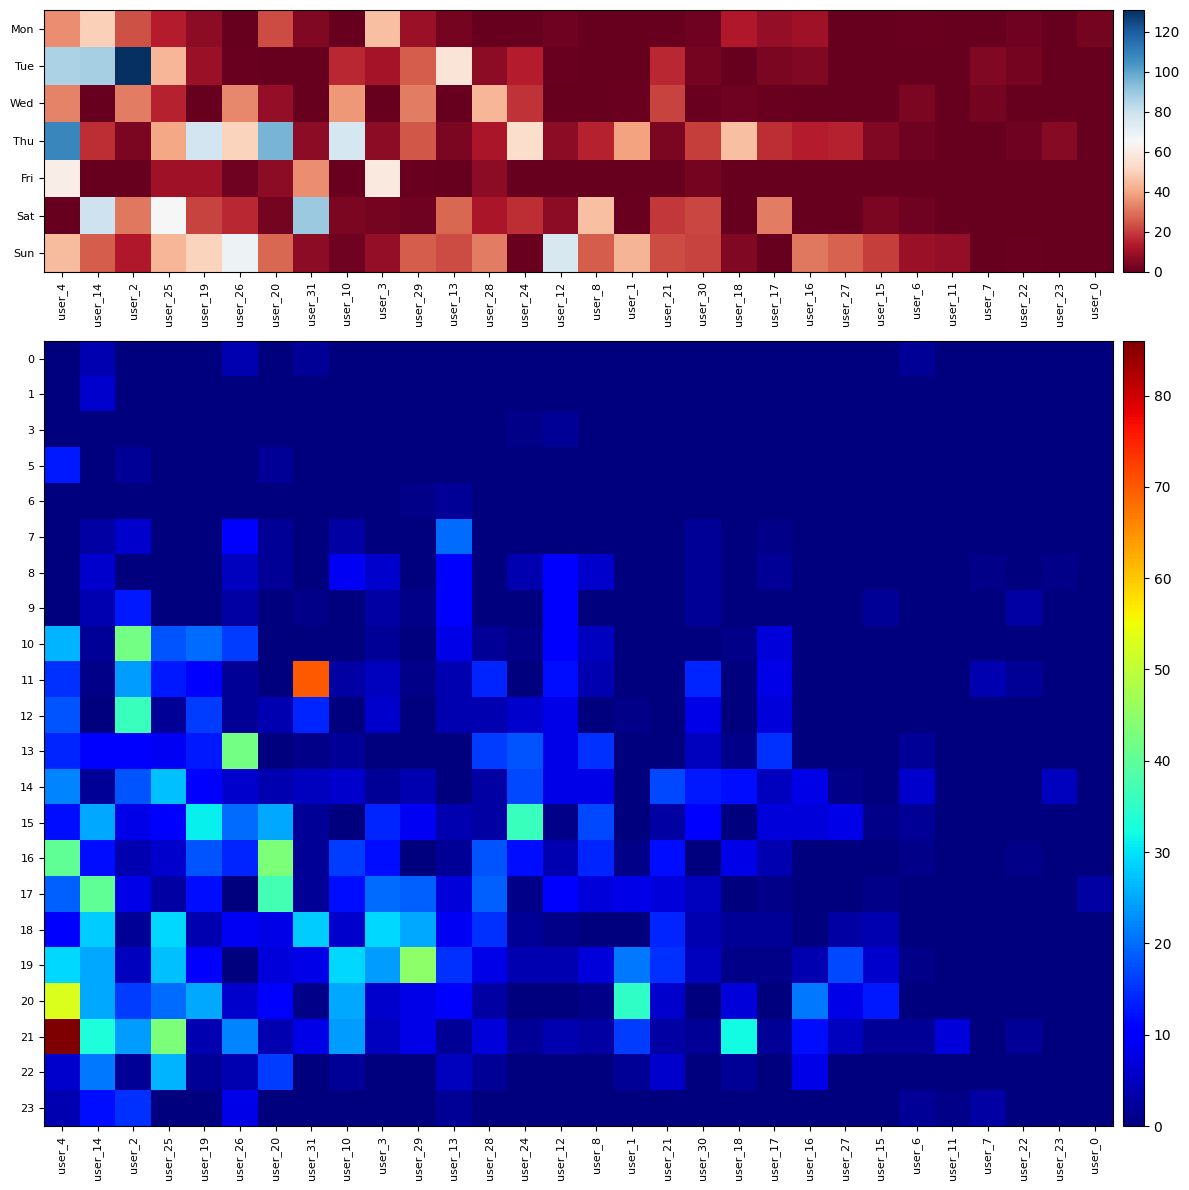

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [1, 3]})

im1 = axes[0].imshow(weekday_pivot.values, cmap='RdBu', aspect='auto')
axes[0].set_xticks(range(len(weekday_pivot.columns)))
axes[0].set_xticklabels(weekday_pivot.columns, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(weekday_pivot.index)))
axes[0].set_yticklabels([day[:3] for day in weekday_pivot.index], fontsize=8)
divider1 = make_axes_locatable(axes[0])
cax1 = divider1.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im1, cax=cax1)

im2 = axes[1].imshow(hour_pivot.values, cmap='jet', aspect='auto')
axes[1].set_xticks(range(len(hour_pivot.columns)))
axes[1].set_xticklabels(hour_pivot.columns, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(hour_pivot.index)))
axes[1].set_yticklabels(hour_pivot.index, fontsize=8)
divider2 = make_axes_locatable(axes[1])
cax2 = divider2.append_axes("right", size="2%", pad=0.1)
plt.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

In [8]:
conn.close()

У какого пользователя больше всего коммитов во вторник?

**user_2**

У какого пользователя больше всего коммитов в четверг?

**user_4**

В какой день недели пользователи не любят делать много коммитов?

**Пятница**

У какого пользователя и в какой час сделано больше всего коммитов?

**user_4, 21**